# Exercise 4 — Linear Regression from Scratch with Gradient Descent

**Goal:** Implement a working linear regression solver using only NumPy — no scikit-learn.  
**Dataset:** Synthetic — `y = 3x + 7 + noise`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SKLearnLR

%matplotlib inline


## Task 1 — Generate Synthetic Data

x range : [-9.85, 9.85]
y range : [-29.96, 42.56]
True w=3.0, b=7.0, noise σ=4.0


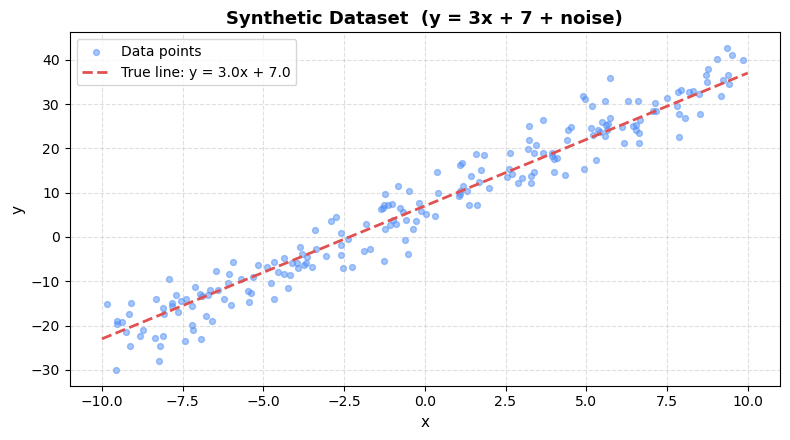

In [2]:
W_TRUE    = 3.0
B_TRUE    = 7.0
NOISE_STD = 4.0
N_POINTS  = 200

rng = np.random.default_rng(42)
x = rng.uniform(-10, 10, N_POINTS)
y = W_TRUE * x + B_TRUE + rng.normal(0, NOISE_STD, N_POINTS)

print(f"x range : [{x.min():.2f}, {x.max():.2f}]")
print(f"y range : [{y.min():.2f}, {y.max():.2f}]")
print(f"True w={W_TRUE}, b={B_TRUE}, noise σ={NOISE_STD}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x, y, alpha=0.5, s=18, color="#4F8EF7", label="Data points")
x_line = np.array([-10, 10])
ax.plot(x_line, W_TRUE * x_line + B_TRUE, color="#E05252", lw=2,
        ls="--", label=f"True line: y = {W_TRUE}x + {B_TRUE}")
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.set_title("Synthetic Dataset  (y = 3x + 7 + noise)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Task 2 — MSE Loss and Gradients

For a single-feature linear model $\hat{y} = wx + b$, the MSE loss over $n$ samples is:

$$\mathcal{L}(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Partial derivatives give the gradients used to update $w$ and $b$:

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)\, x_i
\qquad
\frac{\partial \mathcal{L}}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$


In [3]:
def mse_loss(x, y, w, b):
    """Mean Squared Error loss."""
    y_hat = w * x + b
    return np.mean((y_hat - y) ** 2)


def gradients(x, y, w, b):
    """Analytical gradients of MSE w.r.t. w and b."""
    n     = len(x)
    y_hat = w * x + b
    error = y_hat - y
    dw    = (2 / n) * np.dot(error, x)
    db    = (2 / n) * np.sum(error)
    return dw, db


# Sanity check: gradient at true parameters should be near zero
dw0, db0 = gradients(x, y, W_TRUE, B_TRUE)
print(f"Gradient at true (w=3, b=7): dw={dw0:.4f}  db={db0:.4f}  (≈0 expected)")
print(f"MSE at true params          : {mse_loss(x, y, W_TRUE, B_TRUE):.4f}  (≈ σ² = {NOISE_STD**2:.1f})")


Gradient at true (w=3, b=7): dw=-8.3481  db=-0.1312  (≈0 expected)
MSE at true params          : 16.4886  (≈ σ² = 16.0)


## Task 3 — Gradient Descent (2000 epochs)

**Update rule:**

$$w \leftarrow w - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}
\qquad
b \leftarrow b - \eta \cdot \frac{\partial \mathcal{L}}{\partial b}$$


In [4]:
def gradient_descent(x, y, lr=0.01, n_epochs=2000, w_init=0.0, b_init=0.0):
    """Vanilla gradient descent for simple linear regression."""
    w, b = w_init, b_init
    loss_history = []

    for _ in range(n_epochs):
        loss = mse_loss(x, y, w, b)
        dw, db = gradients(x, y, w, b)
        w -= lr * dw
        b -= lr * db
        loss_history.append(loss)

    return w, b, np.array(loss_history)


LR     = 0.01
EPOCHS = 2000

w_gd, b_gd, loss_hist = gradient_descent(x, y, lr=LR, n_epochs=EPOCHS)

print(f"Gradient Descent — {EPOCHS} epochs, lr={LR}")
print(f"  Final w   : {w_gd:.6f}   (true: {W_TRUE})")
print(f"  Final b   : {b_gd:.6f}   (true: {B_TRUE})")
print(f"  Final MSE : {loss_hist[-1]:.6f}")


Gradient Descent — 2000 epochs, lr=0.01
  Final w   : 3.131842   (true: 3.0)
  Final b   : 7.081784   (true: 7.0)
  Final MSE : 15.932937


## Task 4 — Loss Curve + Fitted Line Plot

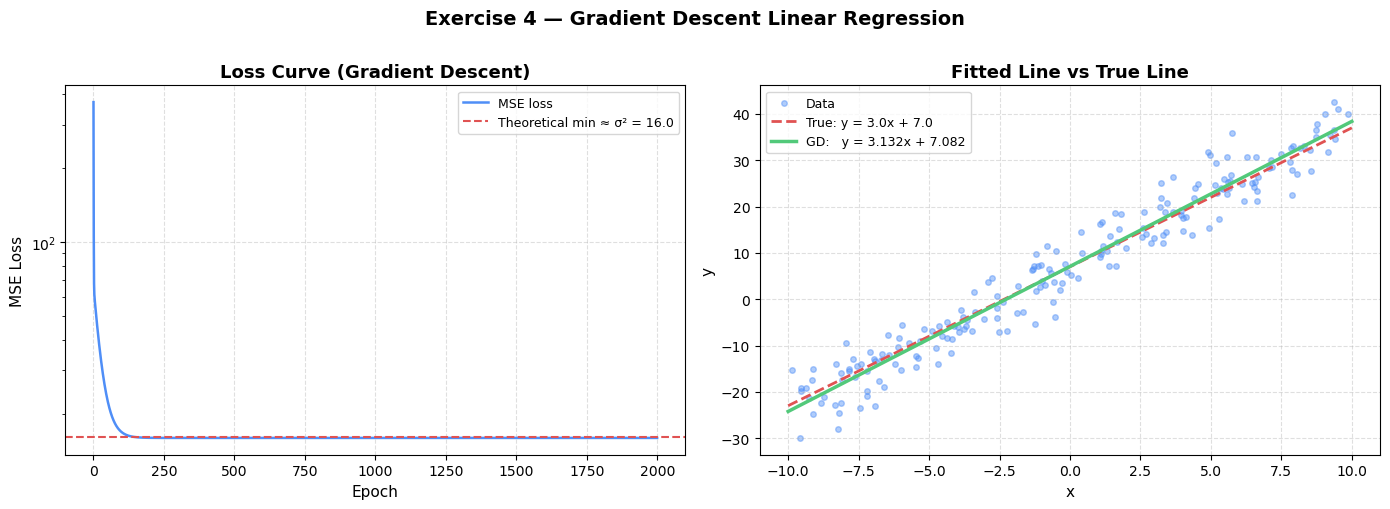

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Loss vs epoch ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(loss_hist, color="#4F8EF7", lw=1.8, label="MSE loss")
ax.axhline(NOISE_STD**2, color="#E05252", lw=1.5, ls="--",
           label=f"Theoretical min ≈ σ² = {NOISE_STD**2:.1f}")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE Loss", fontsize=11)
ax.set_title("Loss Curve (Gradient Descent)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.4)
ax.set_yscale("log")

# ── Right: Scatter + fitted line ───────────────────────────────────────────────
ax = axes[1]
ax.scatter(x, y, alpha=0.45, s=16, color="#4F8EF7", label="Data")
x_line = np.linspace(-10, 10, 200)
ax.plot(x_line, W_TRUE * x_line + B_TRUE,
        color="#E05252", lw=2, ls="--", label=f"True: y = {W_TRUE}x + {B_TRUE}")
ax.plot(x_line, w_gd * x_line + b_gd,
        color="#52C97A", lw=2.5, label=f"GD:   y = {w_gd:.3f}x + {b_gd:.3f}")
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.set_title("Fitted Line vs True Line", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.4)

fig.suptitle("Exercise 4 — Gradient Descent Linear Regression",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Task 5 — Compare with sklearn LinearRegression

In [6]:
sk_model = SKLearnLR()
sk_model.fit(x.reshape(-1, 1), y)

w_sk  = sk_model.coef_[0]
b_sk  = sk_model.intercept_
mse_sk = mse_loss(x, y, w_sk, b_sk)

print("=" * 56)
print(f"{'':18s} {'w':>10s}  {'b':>10s}  {'MSE':>10s}")
print("=" * 56)
print(f"{'True parameters':<18s} {W_TRUE:>10.6f}  {B_TRUE:>10.6f}  {'—':>10s}")
print(f"{'Gradient Descent':<18s} {w_gd:>10.6f}  {b_gd:>10.6f}  {loss_hist[-1]:>10.6f}")
print(f"{'sklearn (OLS)':<18s} {w_sk:>10.6f}  {b_sk:>10.6f}  {mse_sk:>10.6f}")
print("=" * 56)
print(f"\nΔw  (GD − sklearn) : {w_gd - w_sk:+.8f}")
print(f"Δb  (GD − sklearn) : {b_gd - b_sk:+.8f}")
print(f"ΔMSE(GD − sklearn) : {loss_hist[-1] - mse_sk:+.8f}")


                            w           b         MSE
True parameters      3.000000    7.000000           —
Gradient Descent     3.131842    7.081784   15.932937
sklearn (OLS)        3.131842    7.081784   15.932937

Δw  (GD − sklearn) : +0.00000000
Δb  (GD − sklearn) : -0.00000000
ΔMSE(GD − sklearn) : +0.00000000


## ⭐ Bonus — L2 Regularisation (Ridge Gradient Descent)

Adding an L2 penalty to the loss:

$$\mathcal{L}_{\text{ridge}}(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 + \lambda w^2$$

The gradient of $w$ gains an extra term (bias $b$ is conventionally not regularised):

$$\frac{\partial \mathcal{L}_{\text{ridge}}}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)\, x_i + 2\lambda w
\qquad
\frac{\partial \mathcal{L}_{\text{ridge}}}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$


In [7]:
def gradient_descent_l2(x, y, lr=0.01, n_epochs=2000, lam=0.0):
    """Gradient descent with optional L2 regularisation on w (not b)."""
    w, b = 0.0, 0.0
    loss_history = []

    for _ in range(n_epochs):
        n     = len(x)
        y_hat = w * x + b
        error = y_hat - y

        loss = np.mean(error ** 2) + lam * w ** 2
        loss_history.append(loss)

        dw = (2 / n) * np.dot(error, x) + 2 * lam * w
        db = (2 / n) * np.sum(error)

        w -= lr * dw
        b -= lr * db

    return w, b, np.array(loss_history)


import pandas as pd

lambdas = [0.0, 0.1, 1.0, 5.0, 20.0]
colors  = ["#4F8EF7", "#52C97A", "#F7C948", "#F7A84F", "#E05252"]
l2_rows = []

for lam in lambdas:
    w_l2, b_l2, _ = gradient_descent_l2(x, y, lr=LR, n_epochs=EPOCHS, lam=lam)
    mse_l2 = mse_loss(x, y, w_l2, b_l2)   # pure MSE (no penalty) for fair comparison
    l2_rows.append({"λ": lam, "w": round(w_l2, 6), "b": round(b_l2, 6), "MSE (no penalty)": round(mse_l2, 6)})

l2_df = pd.DataFrame(l2_rows)
print("L2 regularisation sweep:")
print(l2_df.to_string(index=False))


L2 regularisation sweep:
   λ        w        b  MSE (no penalty)
 0.0 3.131842 7.081784         15.932937
 0.1 3.122000 7.080577         15.936010
 1.0 3.036127 7.070048         16.223539
 5.0 2.705399 7.029498         21.701427
20.0 1.920779 6.933297         62.456624


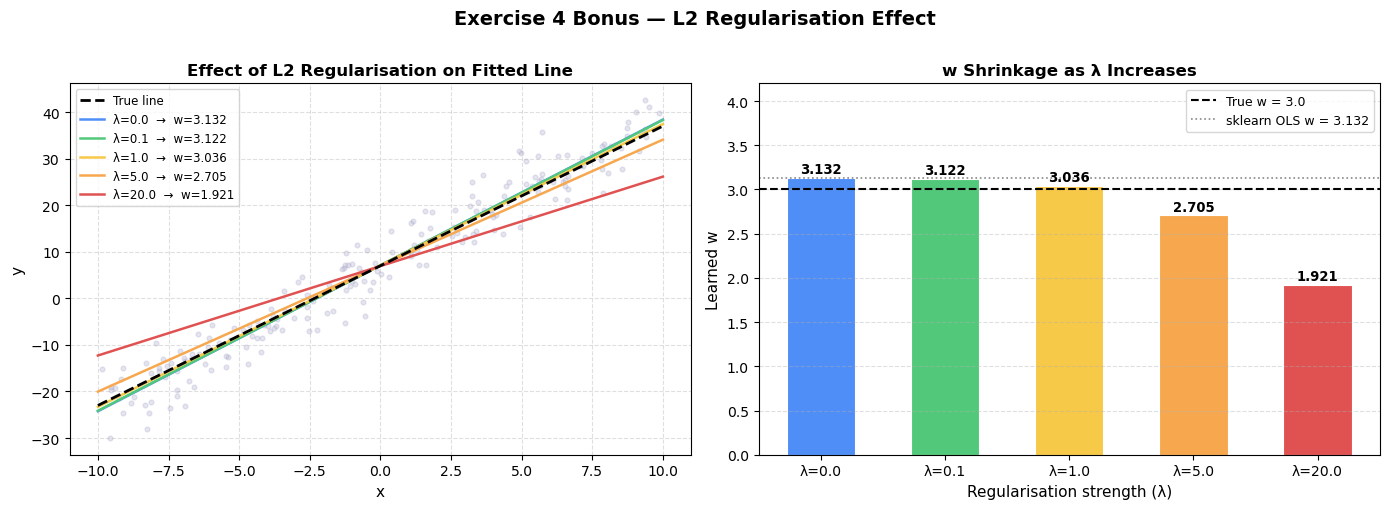

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: fitted lines for each λ ─────────────────────────────────────────────
ax = axes[0]
ax.scatter(x, y, alpha=0.3, s=12, color="#aaaacc", zorder=1)
ax.plot(x_line, W_TRUE * x_line + B_TRUE,
        color="black", lw=2, ls="--", zorder=5, label="True line")

for row, col in zip(l2_rows, colors):
    lam, w_l2, b_l2 = row["λ"], row["w"], row["b"]
    ax.plot(x_line, w_l2 * x_line + b_l2, color=col, lw=1.8,
            label=f"λ={lam}  →  w={w_l2:.3f}")

ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.set_title("Effect of L2 Regularisation on Fitted Line", fontsize=12, fontweight="bold")
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(True, ls="--", alpha=0.4)

# ── Right: w shrinkage bar chart ───────────────────────────────────────────────
ax2 = axes[1]
w_vals     = [row["w"] for row in l2_rows]
lam_labels = [f"λ={row['λ']}" for row in l2_rows]
bars = ax2.bar(lam_labels, w_vals, color=colors, edgecolor="white", lw=0.8, width=0.55)
ax2.axhline(W_TRUE, color="black", lw=1.5, ls="--", label=f"True w = {W_TRUE}")
ax2.axhline(w_sk,   color="#888888", lw=1.2, ls=":", label=f"sklearn OLS w = {w_sk:.3f}")

for bar, val in zip(bars, w_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

ax2.set_xlabel("Regularisation strength (λ)", fontsize=11)
ax2.set_ylabel("Learned w", fontsize=11)
ax2.set_title("w Shrinkage as λ Increases", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, ls="--", alpha=0.4, axis="y")
ax2.set_ylim(0, W_TRUE * 1.4)

fig.suptitle("Exercise 4 Bonus — L2 Regularisation Effect",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 📝 Interpretation

The penalty term $\lambda w^2$ adds $2\lambda w$ to the gradient of $w$ at every step, making the update rule:

$$w \leftarrow w\,(1 - 2\eta\lambda) - \eta \cdot \frac{2}{n}\sum (\hat{y}_i - y_i)\,x_i$$

The factor $(1 - 2\eta\lambda)$ **shrinks** $w$ toward zero at every epoch — hence the name *weight decay*.

| λ | Effect |
|---|---|
| `0.0` | Pure OLS — recovers the true $w ≈ 3$ |
| `0.1` | Tiny shrinkage, negligible bias |
| `1.0` | Noticeable pull toward zero |
| `5.0` | Strong bias; model trades variance for bias |
| `20.0` | Severe underfitting; $w$ collapses toward 0 |

**Key takeaway:** L2 regularisation is most useful when features are collinear or the model is prone to overfitting. For a simple 1-feature dataset like this one, any $\lambda > 0$ only introduces bias without reducing variance.
